# COSMOS Fitting (DP2v7): PSF-CModel mixture fits on COSMOS data

This notebook applies the **v7 fitting procedure** (free star-component mean + skew-normal resolved + 3 components in faint bins) to the **COSMOS DP2** data.

- **Bright bins** (CModel < 22): 1 Gaussian (unresolved, free mean) + **2 skew-normal** (resolved)
- **Faint bins** (CModel >= 22): 1 Gaussian (unresolved, free mean) + **3 skew-normal** (resolved)

The fitting is identical to ECDFS-DP2v7 Task 1. Output plots are saved as `slice_fits_zoomed_DP2v7_COSMOS_{band}.png`.

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sys
sys.path.append('../src')
import pipeline as pipl
import psf_cmodel_fit as pcf
from config import *

# Loading the COSMOS data

In [3]:
data = pipl.load_csv_dp2('../data/private/DP2_COSMOS_objects.fits')
print(f'COSMOS DP2 objects: {len(data):,}')
data.head()

COSMOS DP2 objects: 865,287


,objectId,coord_ra,coord_dec,ebv,refBand,refExtendedness,detect_fromBlend,detect_isIsolated,parentObjectId,u_psfFlux,...,y_extendedness_flag,y_blendedness,y_blendedness_flag,y_pixelFlags_inexact_psfCenter,g_cModelMag,g_cModelMagErr,r_cModelMag,r_cModelMagErr,i_cModelMag,i_cModelMagErr
0,788010362900318671,150.930472,1.488274,0.026183,b'i',0.0,False,True,0,37.689739,...,True,NaN,True,False,26.496537,0.158418,25.345144,0.070689,25.315547,0.105648
1,788010362900318679,150.941913,1.488350,0.026330,b'i',1.0,False,True,0,-15.317045,...,True,0.011235,True,False,28.788401,1.698518,28.704317,1.789533,25.905435,0.224598
2,788010362900318691,150.948242,1.488776,0.026455,b'i',1.0,False,True,0,-28.197121,...,True,0.000000,True,False,27.308365,0.334380,26.121324,0.143641,26.034796,0.205399
3,788010362900318707,150.963171,1.489260,0.026808,b'g',1.0,False,True,0,114.782349,...,True,NaN,True,False,25.462370,0.067000,25.327279,0.078824,25.417572,0.127100
4,788010362900318708,150.986988,1.489517,0.027286,b'i',1.0,False,True,0,504.678833,...,False,0.000000,False,False,24.042238,0.022368,23.527614,0.017884,23.137469,0.019768


# Magnitude calculations

In [4]:
data_mag = pipl.magnitude_calculations(data, data['ebv'] * 3.10 / 1.20)
data_mag.head()

c:\Users\Nemal\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\Nemal\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\Nemal\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\Nemal\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\Nemal\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\Nemal\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountere

,objectId,coord_ra,coord_dec,ebv,refBand,refExtendedness,detect_fromBlend,detect_isIsolated,parentObjectId,u_psfFlux,...,z_psfRelErr,y_diff,y_psfRelErr,ug,gr,ri,iz,zy,gi,Ar
0,788010362900318671,150.930472,1.488274,0.026183,b'i',0.0,False,True,0,37.689739,...,0.177819,0.125284,1.078469,1.175782,1.124337,0.013297,0.303287,-0.494017,1.137634,0.067638
1,788010362900318679,150.941913,1.488350,0.026330,b'i',1.0,False,True,0,-15.317045,...,-1.676510,NaN,-0.319233,NaN,0.056876,2.782493,NaN,NaN,2.839369,0.068018
2,788010362900318691,150.948242,1.488776,0.026455,b'i',1.0,False,True,0,-28.197121,...,0.488495,-0.522823,2.081359,NaN,1.159703,0.070058,-0.066543,-0.811166,1.229761,0.068343
3,788010362900318707,150.963171,1.489260,0.026808,b'g',1.0,False,True,0,114.782349,...,0.284186,0.526944,4.557587,0.697038,0.107392,-0.106984,-0.004811,-1.287280,0.000408,0.069253
4,788010362900318708,150.986988,1.489517,0.027286,b'i',1.0,False,True,0,504.678833,...,0.025609,0.360113,0.065368,0.252794,0.486428,0.373156,0.613334,0.284372,0.859584,0.070490


# Fit PSF-CModel histograms in CModel slices (per filter)
Free star mean (bounded to [-0.05, 0.02]) + skew-normal resolved components.
- **Bright bins** (< 22): 2 skew-normal resolved components, padded to 3-component layout.
- **Faint bins** (22-25): 3 skew-normal resolved components.

--- fitting filter u ---
  bright bins: 5/5 ok, faint bins: 3/3 ok
    bin 15-18: muU = -0.00336
    bin 18-19: muU = -0.00074
    bin 19-20: muU = -0.00112
    bin 20-21: muU = -0.00101
    bin 21-22: muU = -0.00138
    bin 22-23: muU = -0.00112
    bin 23-24: muU = -0.00155
    bin 24-25: muU = -0.00231


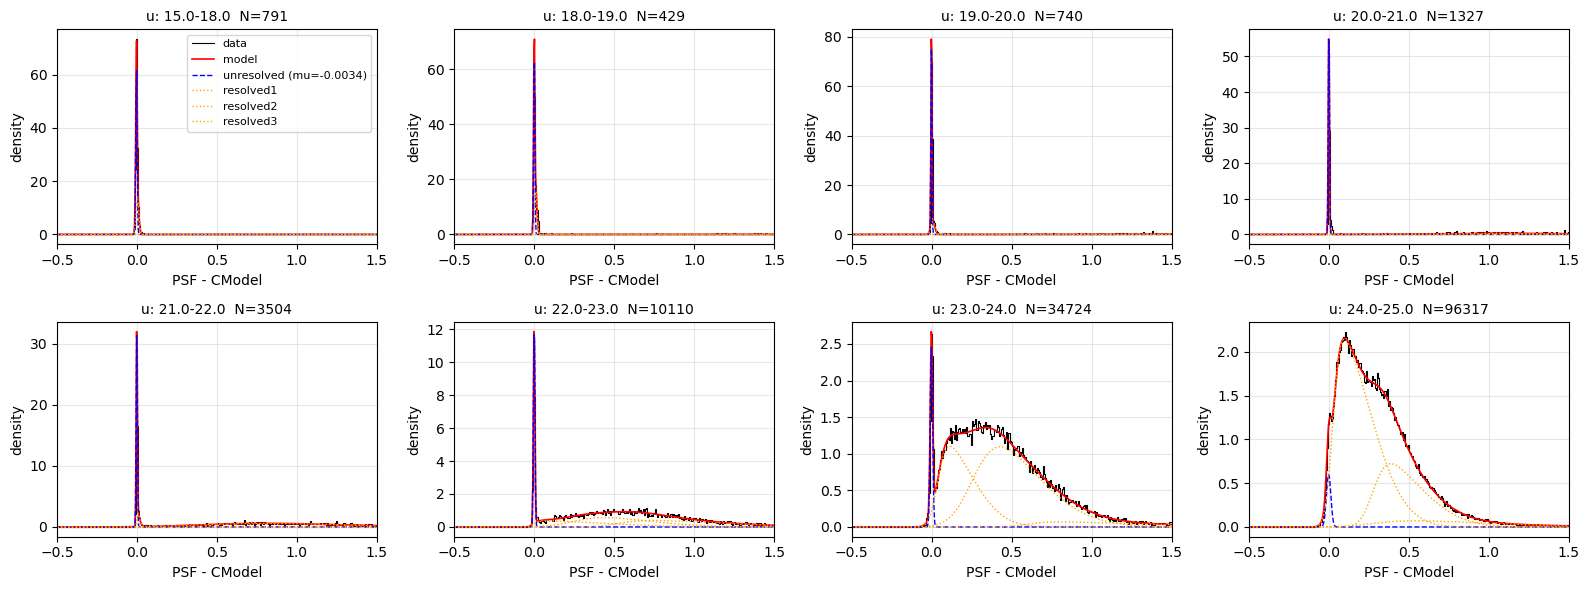

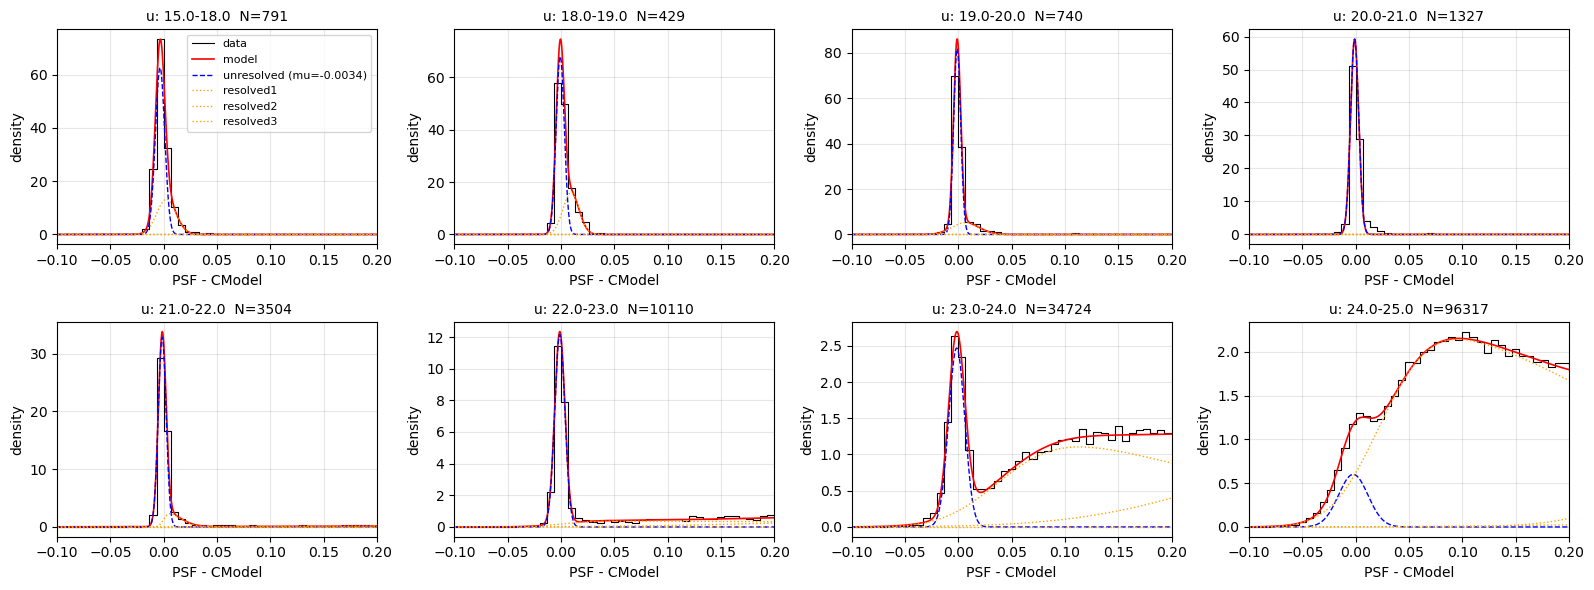

--- fitting filter g ---
  bright bins: 5/5 ok, faint bins: 3/3 ok
    bin 15-18: muU = -0.00025
    bin 18-19: muU = -0.00102
    bin 19-20: muU = -0.00098
    bin 20-21: muU = -0.00131
    bin 21-22: muU = -0.00132
    bin 22-23: muU = -0.00154
    bin 23-24: muU = -0.00186
    bin 24-25: muU = -0.00179


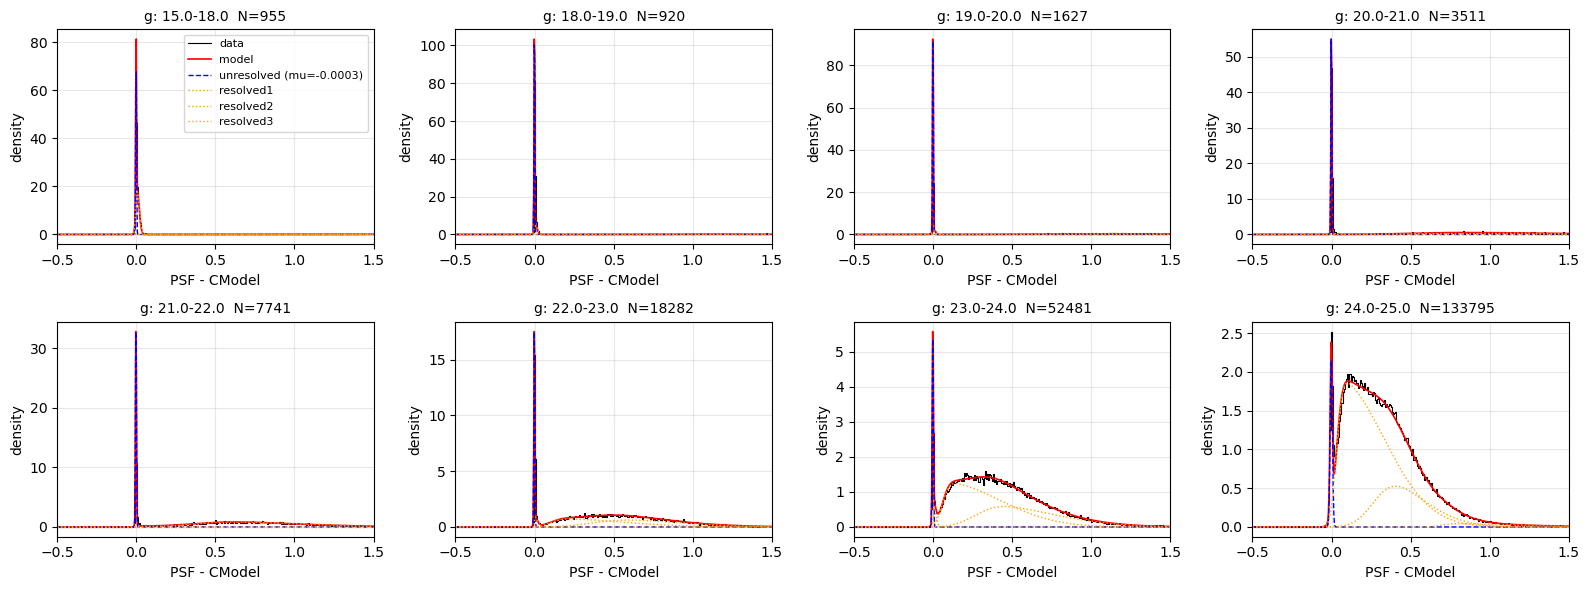

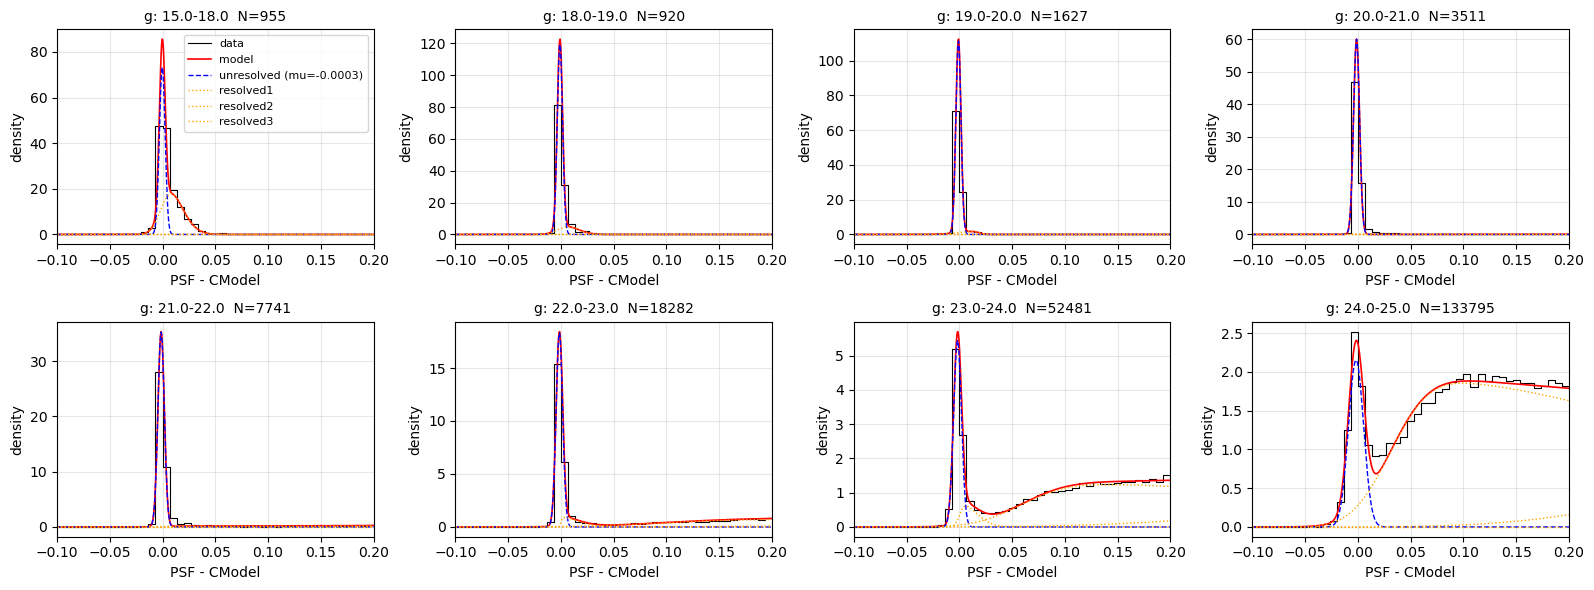

--- fitting filter r ---
  bright bins: 5/5 ok, faint bins: 3/3 ok
    bin 15-18: muU = +0.00052
    bin 18-19: muU = +0.00037
    bin 19-20: muU = -0.00029
    bin 20-21: muU = -0.00038
    bin 21-22: muU = -0.00044
    bin 22-23: muU = -0.00016
    bin 23-24: muU = +0.00067
    bin 24-25: muU = -0.00134


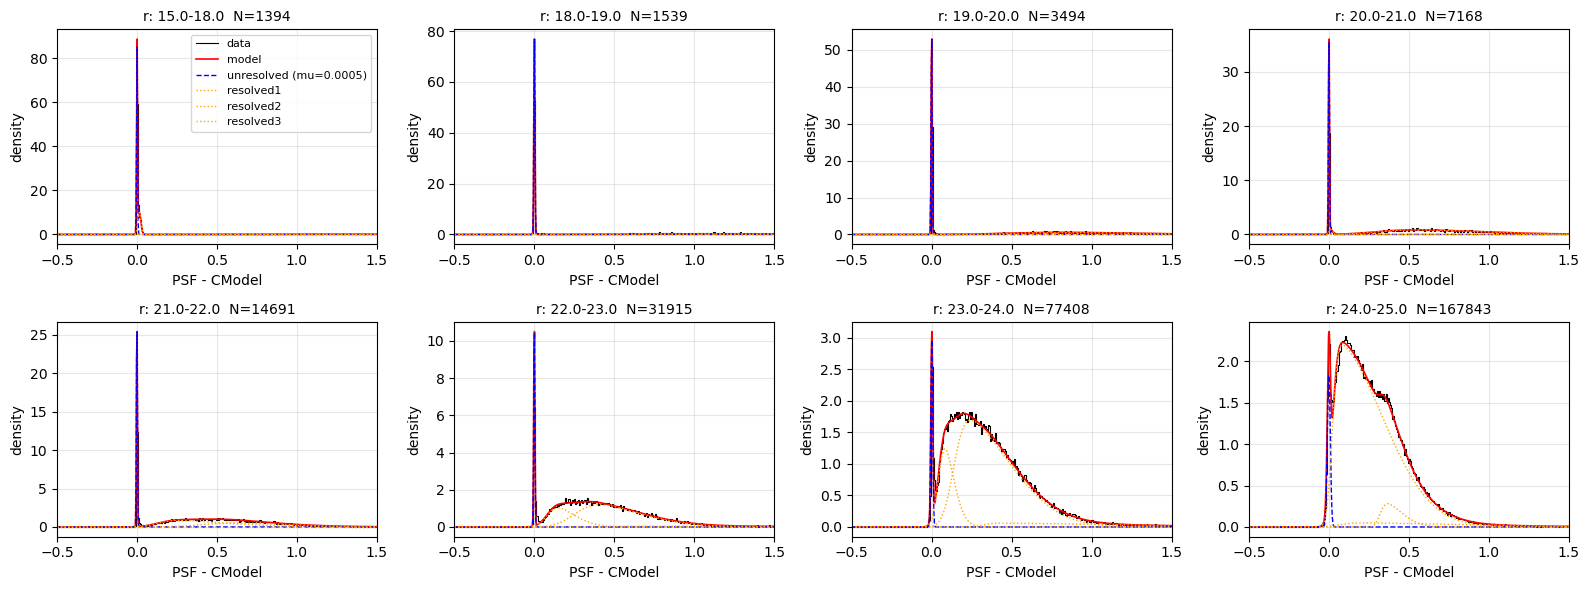

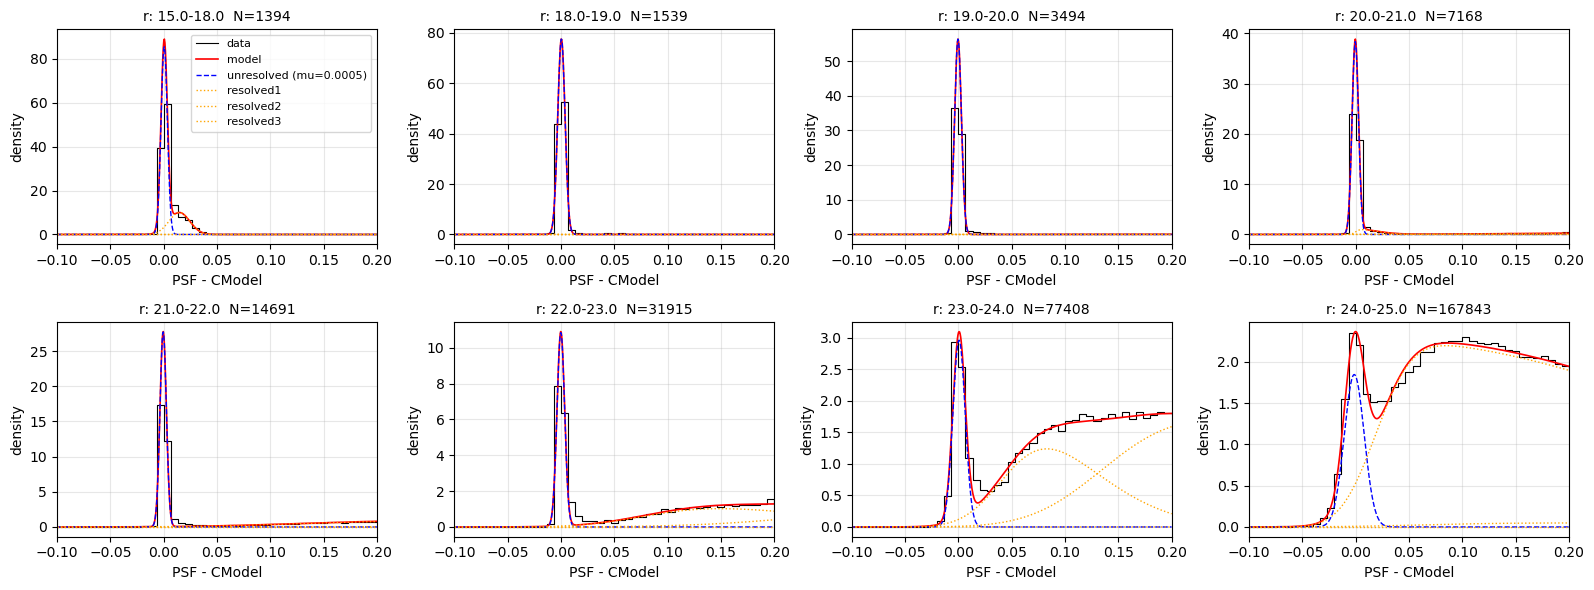

--- fitting filter i ---
  bright bins: 5/5 ok, faint bins: 3/3 ok
    bin 15-18: muU = +0.00189
    bin 18-19: muU = +0.00106
    bin 19-20: muU = +0.00098
    bin 20-21: muU = +0.00129
    bin 21-22: muU = +0.00208
    bin 22-23: muU = -0.00031
    bin 23-24: muU = -0.00087
    bin 24-25: muU = -0.00085


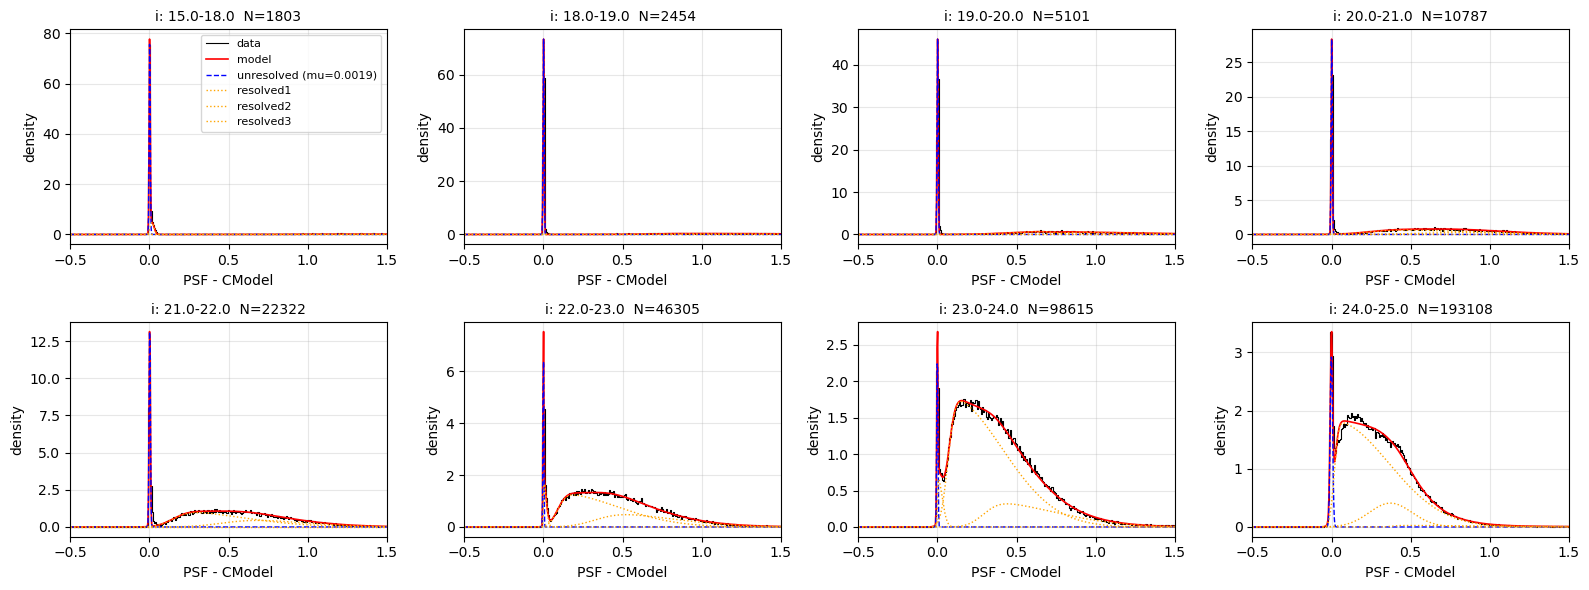

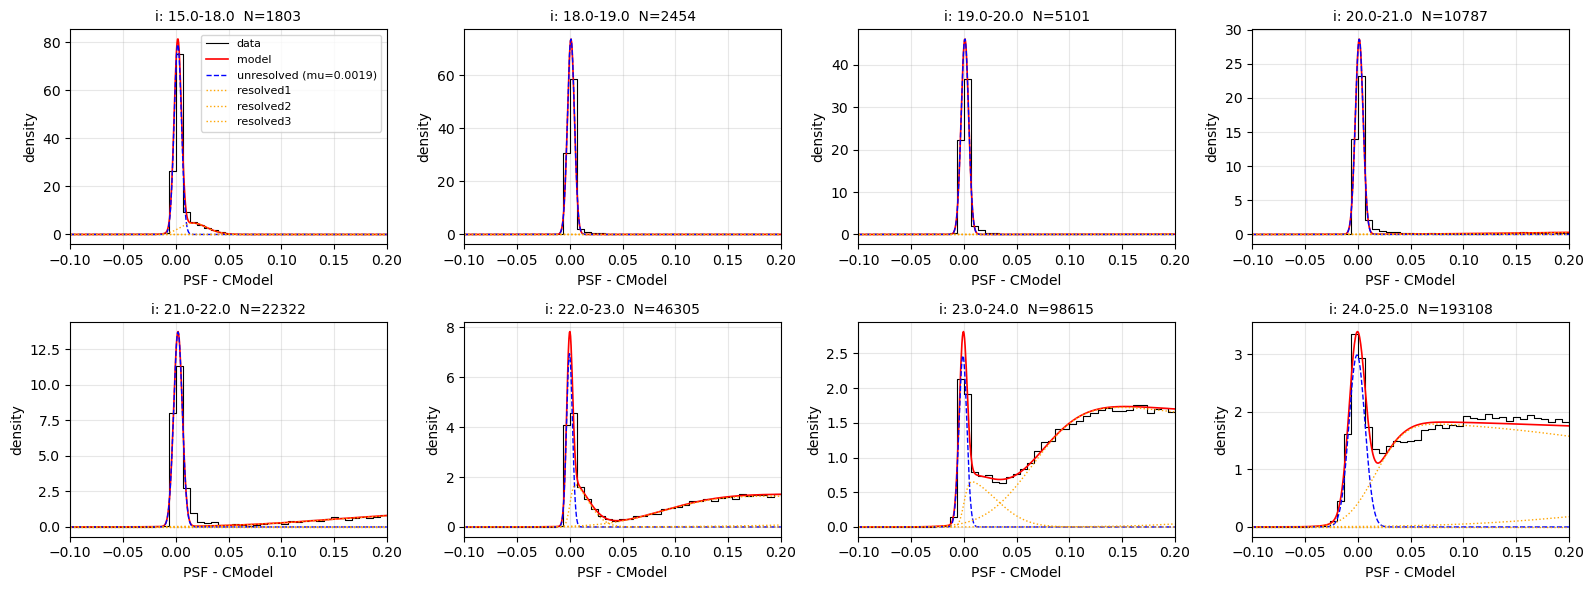

--- fitting filter z ---
  bright bins: 5/5 ok, faint bins: 3/3 ok
    bin 15-18: muU = +0.00214
    bin 18-19: muU = +0.00156
    bin 19-20: muU = +0.00145
    bin 20-21: muU = +0.00194
    bin 21-22: muU = +0.00255
    bin 22-23: muU = +0.00273
    bin 23-24: muU = +0.00310
    bin 24-25: muU = +0.00046


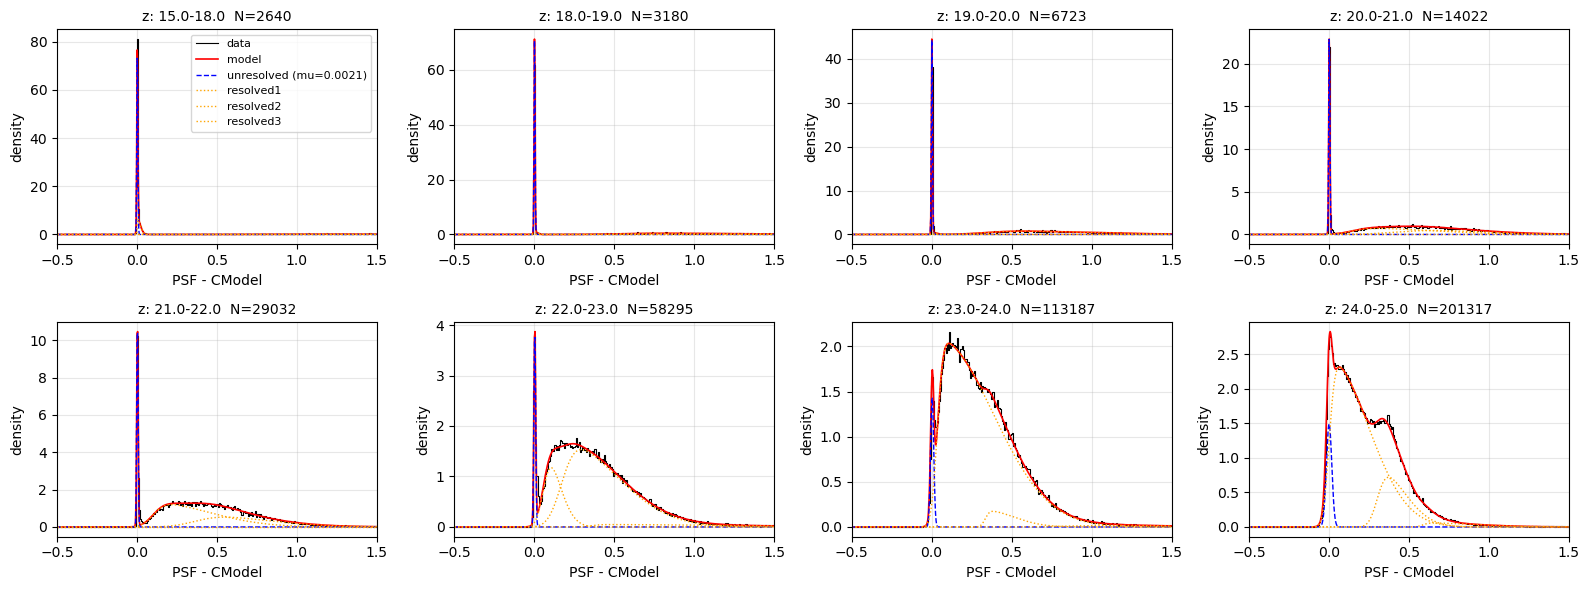

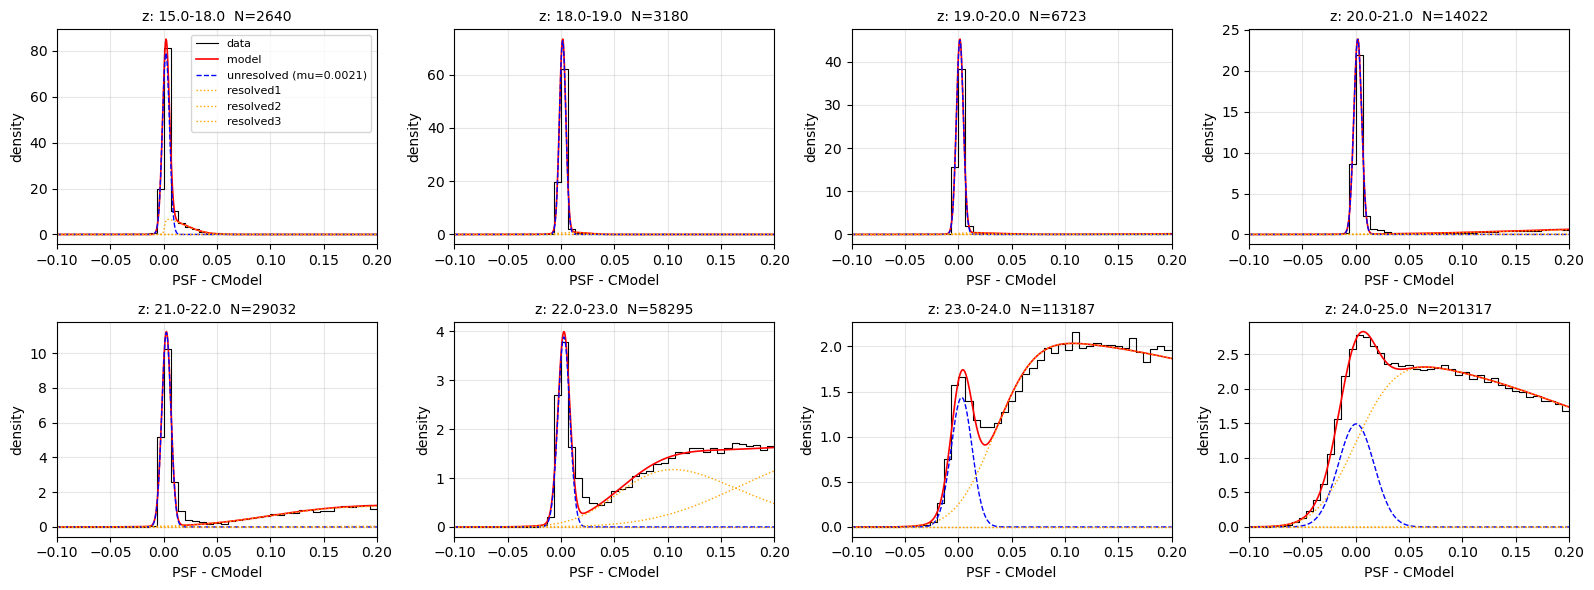

--- fitting filter y ---
  bright bins: 5/5 ok, faint bins: 3/3 ok
    bin 15-18: muU = +0.00760
    bin 18-19: muU = +0.00753
    bin 19-20: muU = +0.00753
    bin 20-21: muU = +0.00821
    bin 21-22: muU = +0.00991
    bin 22-23: muU = +0.01107
    bin 23-24: muU = +0.00650
    bin 24-25: muU = +0.01091


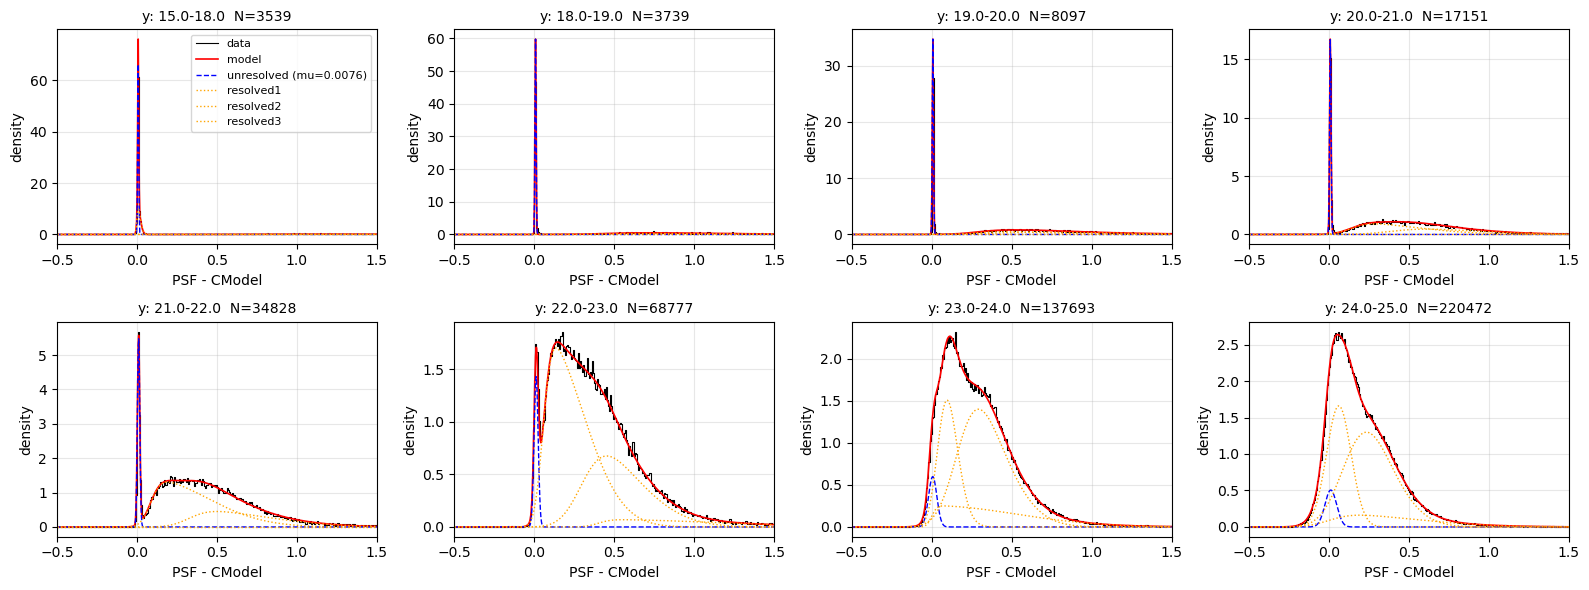

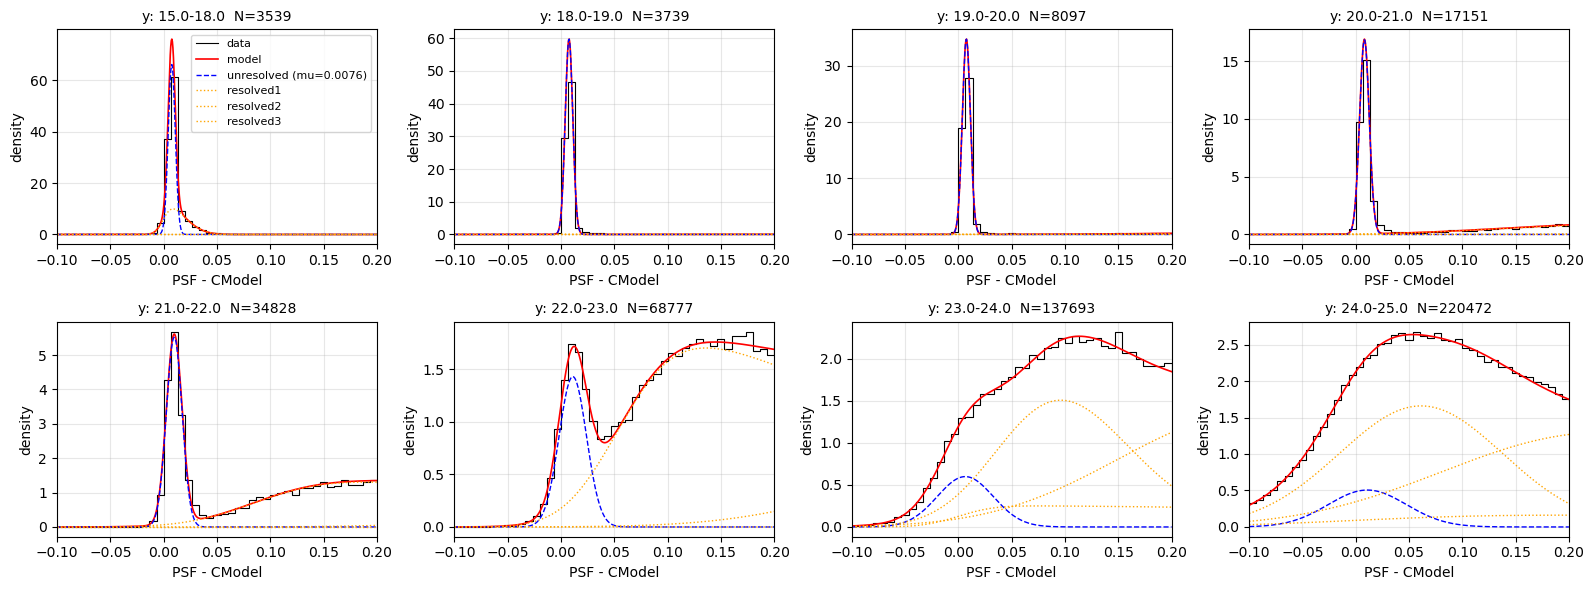

In [5]:
bright_bins = [(15.0, 18.0), (18.0, 19.0), (19.0, 20.0), (20.0, 21.0), (21.0, 22.0)]
faint_bins  = [(22.0, 23.0), (23.0, 24.0), (24.0, 25.0)]

def _pad_2to3_skewnorm_freemu(result):
    """Pad a 2-resolved skewnorm (free mu) fit result to 3-resolved layout (wR3=0)."""
    r = dict(result)
    r['n_resolved'] = 3
    if r['params'] is not None:
        p = list(r['params'])
        p += [0.0, 0.5, 0.2, 0.0]  # wR3=0, muR3=0.5, sigmaR3=0.2, alphaR3=0
        r['params'] = np.array(p)
    return r

slice_fits = {}
for band in ['u', 'g', 'r', 'i', 'z', 'y']:
    print(f'--- fitting filter {band} ---')
    fits_bright = pcf.fit_slices(data_mag, band, n_resolved=2,
                                  cmodel_bins=bright_bins, model_type='skewnorm',
                                  free_star_mean=True)
    fits_faint  = pcf.fit_slices(data_mag, band, n_resolved=3,
                                  cmodel_bins=faint_bins, model_type='skewnorm',
                                  free_star_mean=True)
    combined = [_pad_2to3_skewnorm_freemu(r) for r in fits_bright] + list(fits_faint)
    slice_fits[band] = combined

    n_bright_ok = sum(1 for r in fits_bright if r['success'])
    n_faint_ok  = sum(1 for r in fits_faint  if r['success'])
    print(f'  bright bins: {n_bright_ok}/{len(bright_bins)} ok, '
          f'faint bins: {n_faint_ok}/{len(faint_bins)} ok')

    for r in combined:
        if r['success']:
            muU = r['params'][0]
            print(f'    bin {r["cmodel_lo"]:.0f}-{r["cmodel_hi"]:.0f}: muU = {muU:+.5f}')

    pcf.plot_slice_fits(combined, band,
                        name=f'slice_fits_DP2v7_COSMOS_{band}.png')
    pcf.plot_slice_fits(combined, band, dm_range=(-0.1, 0.2),
                        name=f'slice_fits_zoomed_DP2v7_COSMOS_{band}.png')